# Weak-lensing galaxy shape catalogue validation

## Global metacalibration

Contents.
- Metacalibration (global)
- Additive bias, ellipticity, magnitude distributions

> **_NOTE:_** Before running this notebook, set kernel to `main_set.ipynb'

In [23]:
%matplotlib inline

import os
from uncertainties import ufloat

In [24]:
from sp_validation.survey import *
from sp_validation.basic import *
from sp_validation.util import *
from sp_validation.basic import *
from sp_validation.plots import *
from sp_validation.plot_style import *
from sp_validation.calibration import *

## metacalibration for galaxies


The selection criteria for galaxies are
- Flags = 0 to select valid objects
- $\frac{T_{\rm gal}}{T_{\rm psf}}$ > 0.5  to select objects that are not too small compared to the PSF, thus not likely to be point-like
- SNR > 10 to cut noisy objects
- SNR < 500 to cut too bright objects, potentially too large for the postage stamp

### ngmix

In [25]:
gal_metacal_ngmix = metacal(dd, m_gal_ngmix, snr_min=gal_snr_min, snr_max=gal_snr_max, rel_size_min=gal_rel_size_min, verbose=verbose)

Metacal cuts: 10<snr<500, rel_size_min=0.5
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear


#### Get quantities for plots

In [26]:
g_corr_ngmix, g_uncorr_ngmix, w_ngmix, mask = get_calibrated_quantities(gal_metacal_ngmix)

# coordinates
ra_ngmix = dd['XWIN_WORLD'][m_gal_ngmix][mask]
dec_ngmix = dd['YWIN_WORLD'][m_gal_ngmix][mask]
ra_ngmix_mean = np.mean(ra_ngmix)
dec_ngmix_mean = np.mean(dec_ngmix)

# magnitude, from SExtractor
mag_ngmix = dd['MAG_AUTO'][m_gal_ngmix][mask]

# signal-to-noise ratio, from ngmix fitted flux and error
snr_ngmix = dd['NGMIX_FLUX_NOSHEAR'][m_gal_ngmix][mask]/dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal_ngmix][mask]

In [27]:
# Number density
n_gal_ngmix = len(w_ngmix)
n_gal_ngmix_sm = len(np.where(m_gal_ngmix)[0])

print_stats('ngmix:', stats_file, verbose=verbose)
print_stats('Number of galaxies after metacal = {}/{} = {:.1f}%' \
            ''.format(n_gal_ngmix, n_gal_ngmix_sm, n_gal_ngmix / n_gal_ngmix_sm * 100), stats_file, verbose=verbose)
print_stats('Galaxy density = {:.2f} gal/arcmin2'.format(n_gal_ngmix / area_amin2), stats_file, verbose=verbose)

ngmix:
Number of galaxies after metacal = 1515205/3466497 = 43.7%
Galaxy density = 7.87 gal/arcmin2


#### Plot spatial distribution of objects

In [28]:
x_label = 'R.A. [deg]'
y_label = 'DEC [deg]'
cbar_label_base = 'Density [$A_{\\rm pix}^{-1}$]'

Number of pixels = 438^2


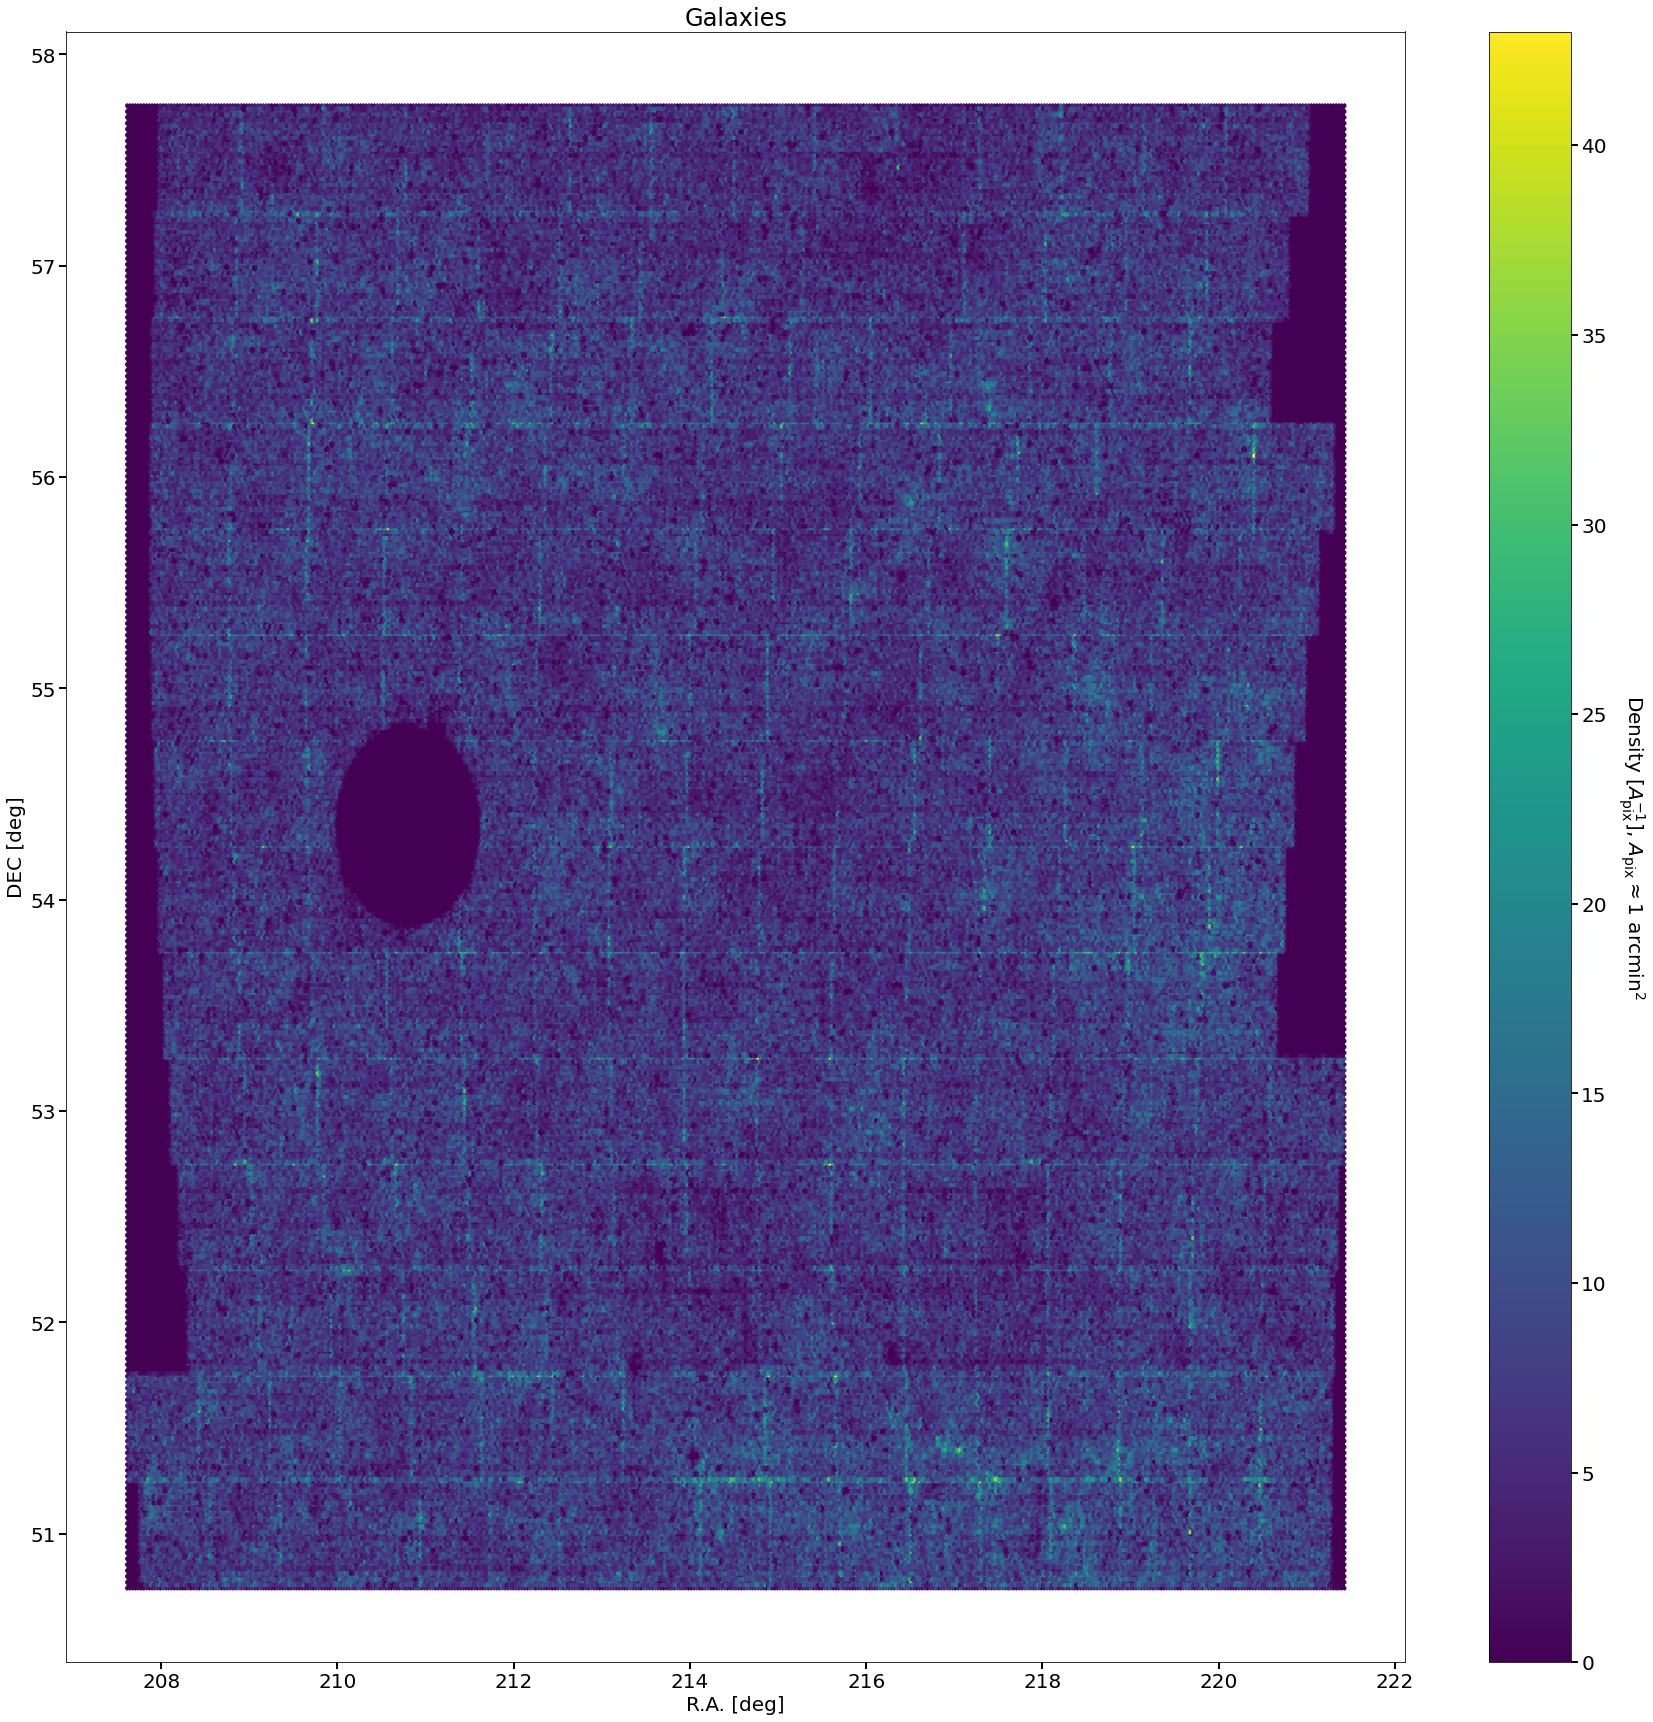

In [29]:
# Galaxies

ra = ra_ngmix
dec = dec_ngmix

Apix = 1 # [arcmin^2]
title = 'Galaxies'
out_name = 'galaxy_number_count_ngmix.png'

cbar_label = '{}, $A_{{\\rm pix}} \\approx {:.1g}$ arcmin$^2$'.format(cbar_label_base, Apix)
out_path = '{}/{}'.format(plot_dir, out_name)
n_grid = int(np.sqrt(area_amin2) / Apix)
if verbose:
    print('Number of pixels = {}^2'.format(n_grid))
plot_spatial_density(ra, dec, title, x_label, y_label, cbar_label, out_path, n_grid=n_grid, verbose=verbose)

#### Plot galaxy signal-to-noise distribution
Plot both ngmix and galsim selection

ngmix:


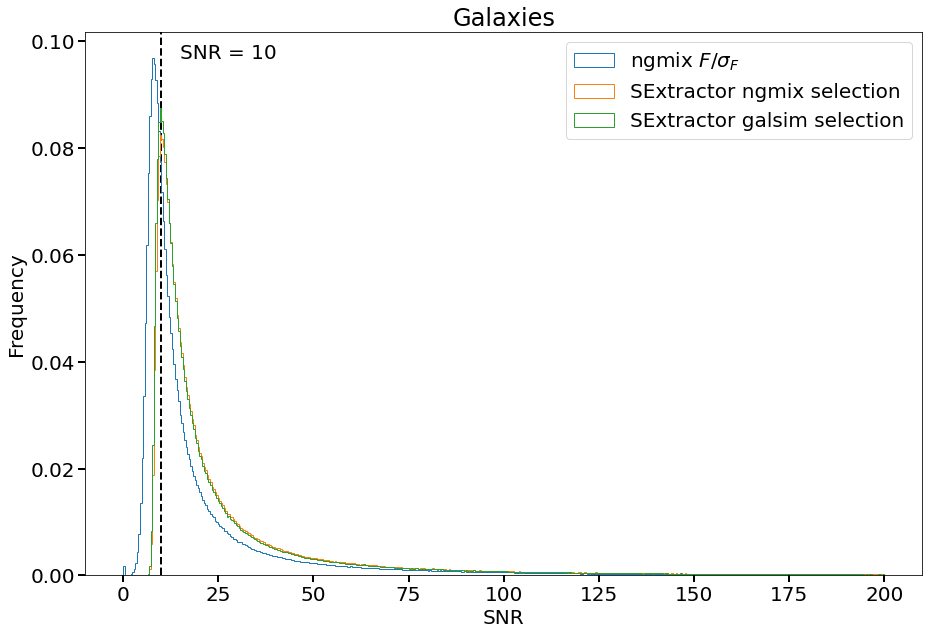

In [30]:
print_stats('ngmix:', stats_file, verbose=verbose)

# Do not apply `mask_ns`, so use all galaxies
xs = [dd['NGMIX_FLUX_NOSHEAR'][m_gal_ngmix]/dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal_ngmix],
      dd['SNR_WIN'][m_gal_ngmix],
      dd['SNR_WIN'][m_gal_galsim],
     ]
labels = ['ngmix $F/\\sigma_F$', 'SExtractor ngmix selection', 'SExtractor galsim selection']

x_label = 'SNR'
y_label = 'Frequency'
title = 'Galaxies'
density = True
x_range = (0, 200)
n_bin = 500
out_name = 'hist_SNR_ngmix.pdf'
out_path = os.path.join(plot_dir, out_name)

x = 10
plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                vline_x=[x], vline_lab=['SNR = {}'.format(x)])

### galsim

In [31]:
gal_metacal_galsim = metacal(dd, m_gal_galsim, prefix='GALSIM', snr_min=gal_snr_min, snr_max=gal_snr_max,
                             rel_size_min=gal_rel_size_min, verbose=verbose)

Metacal cuts: 10<snr<500, rel_size_min=0.5
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear


#### Get quantities for plots

In [32]:
g_corr_galsim, g_uncorr_galsim, w_galsim, mask_galsim = get_calibrated_quantities(gal_metacal_galsim)

# coordinates
ra_galsim = dd['XWIN_WORLD'][m_gal_galsim][mask_galsim]
dec_galsim = dd['YWIN_WORLD'][m_gal_galsim][mask_galsim]

# magnitude, from SExtractor
mag_galsim = dd['MAG_AUTO'][m_gal_galsim][mask_galsim]

# No SNR estimate from galsim

In [33]:
# Number density
n_gal_galsim = len(w_galsim)
n_gal_galsim_sm = len(np.where(m_gal_galsim)[0])


print_stats('galsim:', stats_file, verbose=verbose)
print_stats('Number of galaxies after metacal = {}/{} = {:.1f}%' \
            ''.format(n_gal_galsim, n_gal_galsim_sm, n_gal_galsim / n_gal_galsim_sm * 100), stats_file, verbose=verbose)
print_stats('Galaxy density = {:.2f} gal/arcmin2'.format(n_gal_galsim / area_amin2), stats_file, verbose=verbose)

galsim:
Number of galaxies after metacal = 377473/3330199 = 11.3%
Galaxy density = 1.96 gal/arcmin2


#### Plot spatial distribution of objects

Number of pixels n = 438^2


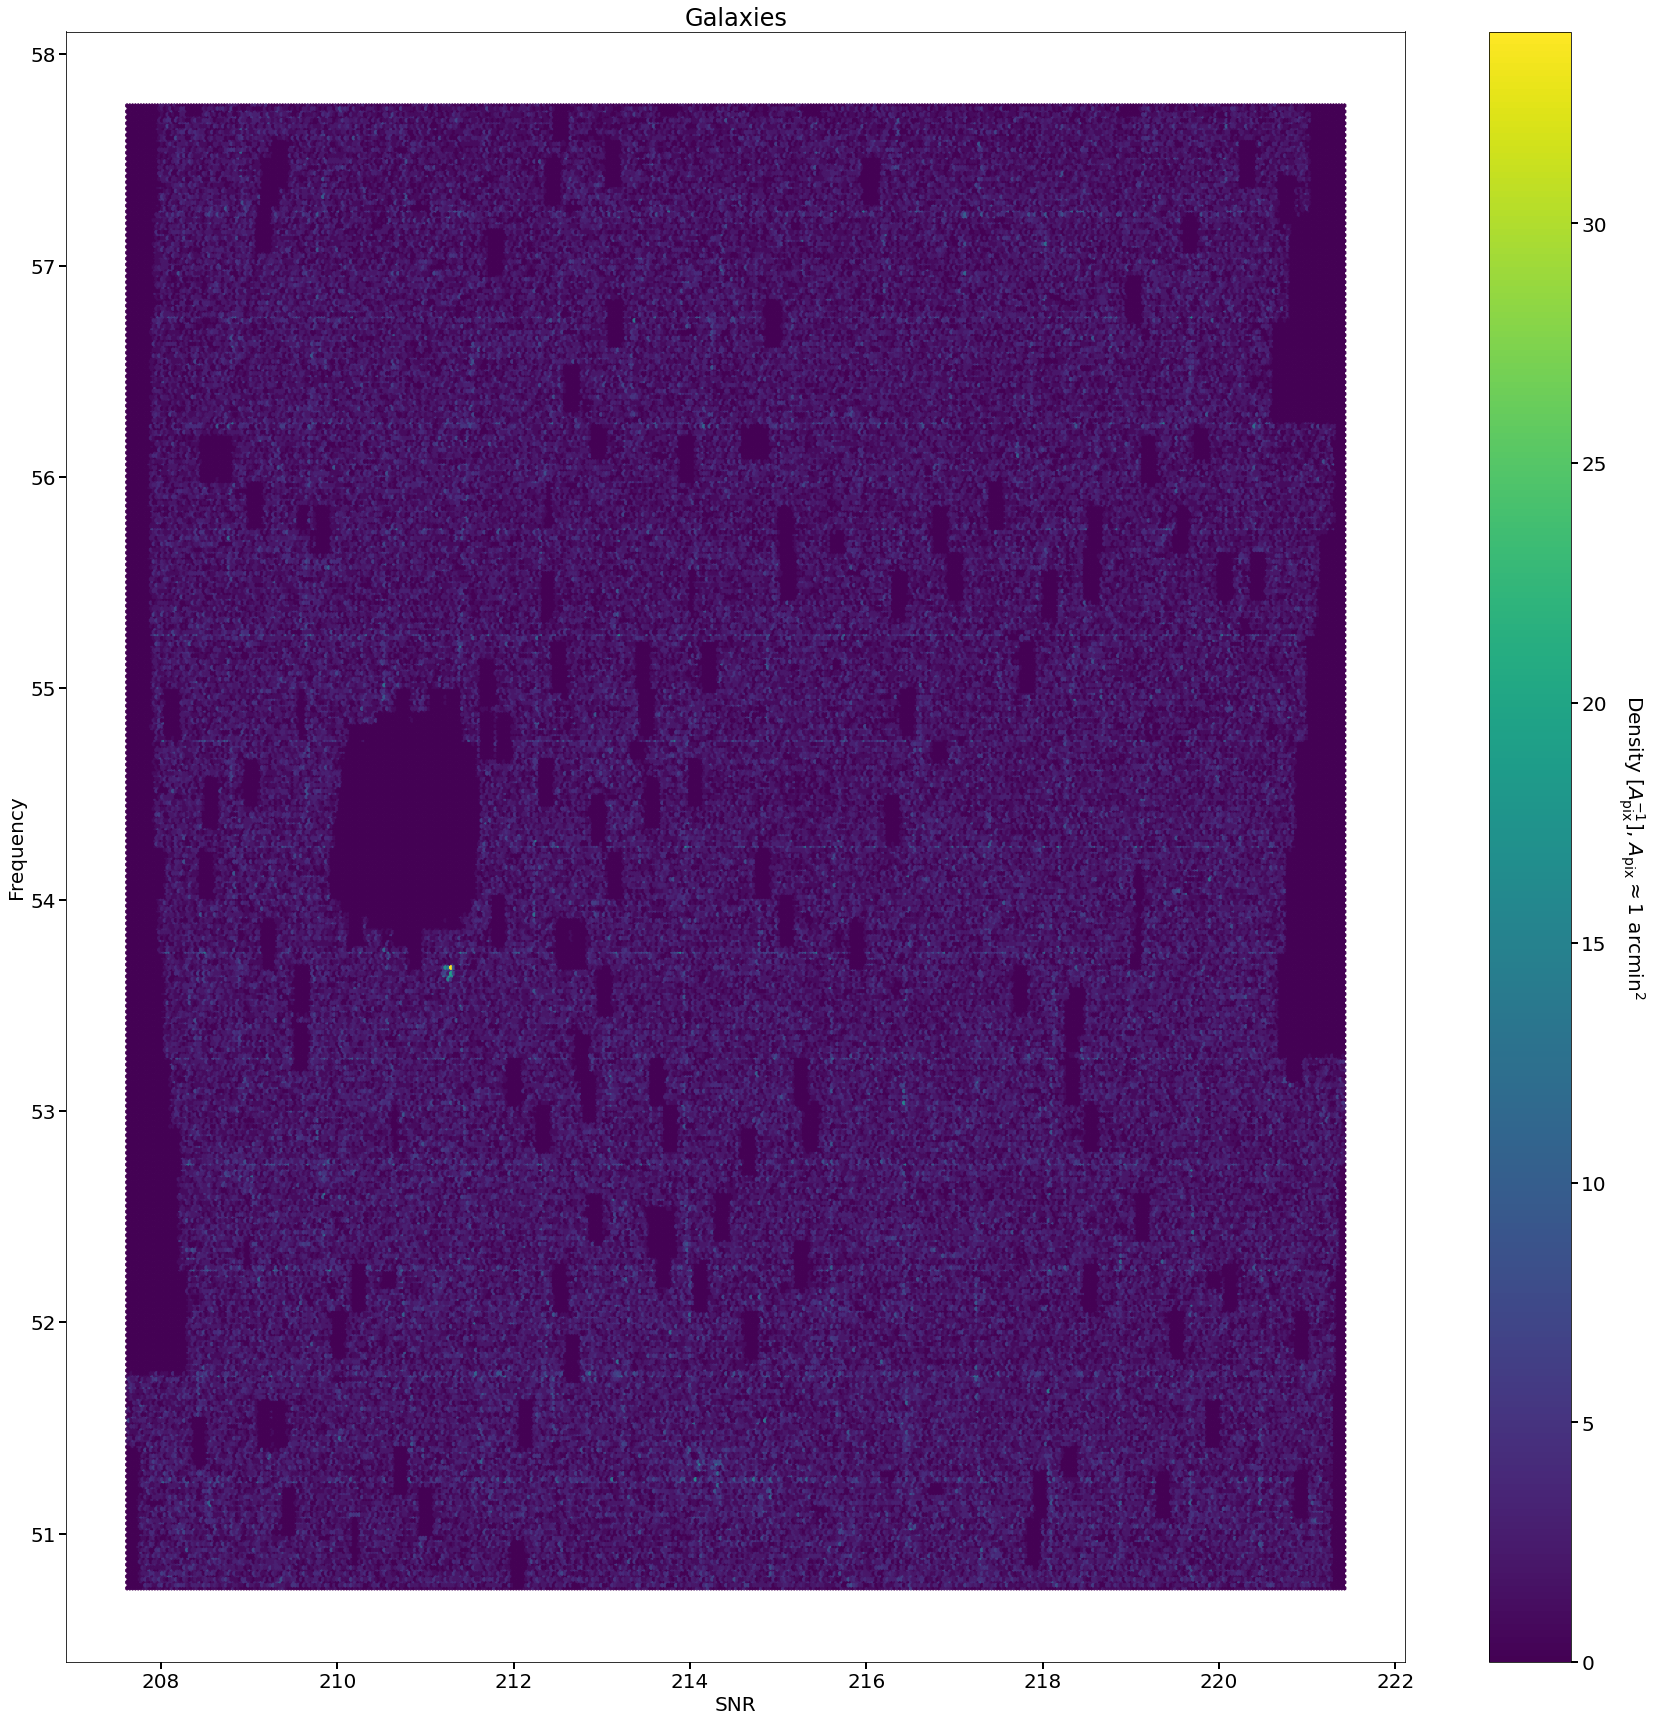

In [34]:
# Galaxies

ra = ra_galsim
dec = dec_galsim

Apix = 1 # [arcmin^2]
title = 'Galaxies'
out_name = 'galaxy_number_count_galsim.png'

cbar_label = '{}, $A_{{\\rm pix}} \\approx {:.1g}$ arcmin$^2$'.format(cbar_label_base, Apix)
out_path = '{}/{}'.format(plot_dir, out_name)
n_grid = int(np.sqrt(area_amin2) / Apix)
if verbose:
    print('Number of pixels n = {}^2'.format(n_grid))
plot_spatial_density(ra, dec, title, x_label, y_label, cbar_label, out_path, n_grid=n_grid, verbose=verbose)

### Common

Number of pixels = 438^2


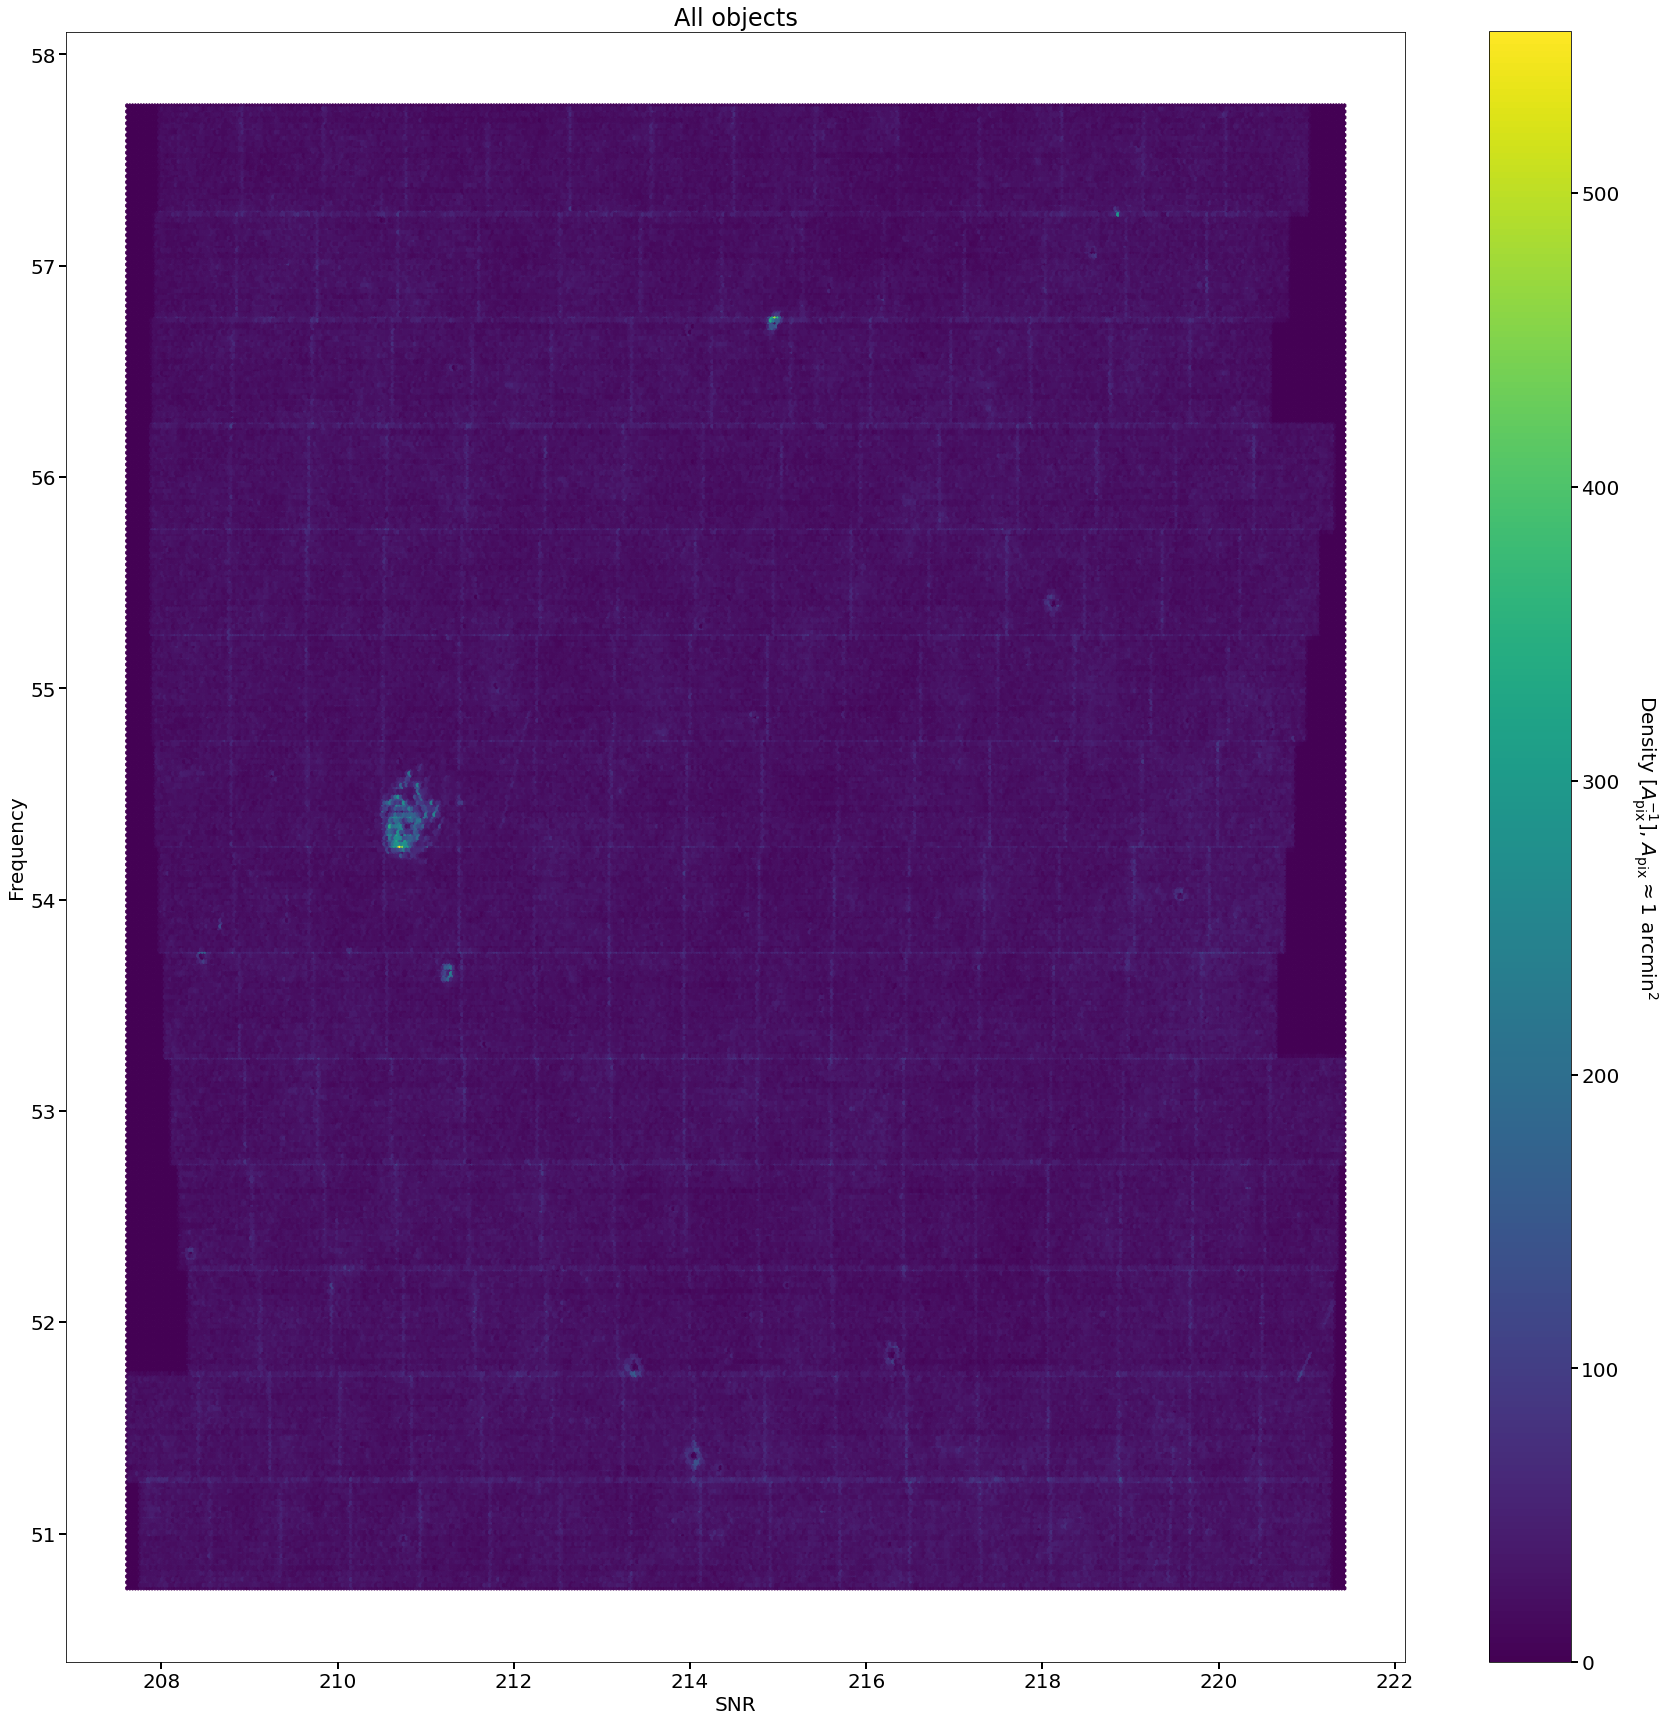

In [35]:
# All objects

ra = dd['XWIN_WORLD']
dec = dd['YWIN_WORLD']

Apix = 1 # [arcmin^2]
title = 'All objects'
out_name = 'object_number_count_ngmix.png'

cbar_label = '{}, $A_{{\\rm pix}} \\approx {:.1g}$ arcmin$^2$'.format(cbar_label_base, Apix)
out_path = '{}/{}'.format(plot_dir, out_name)
n_grid = int(np.sqrt(area_amin2) / Apix)
if verbose:
    print('Number of pixels = {}^2'.format(n_grid))
plot_spatial_density(ra, dec, title, x_label, y_label, cbar_label, out_path, n_grid=n_grid, verbose=verbose)

## Metacalibration for stars

### ngmix

In [36]:
star_metacal_ngmix = metacal(dd[ind_star], m_star_ngmix, masking_type='star')

#### Number density

In [37]:
# mask for 'no shear' images
mask_ns_stars = star_metacal_ngmix.mask_dict['ns']

n_star_ngmix = len(star_metacal_ngmix.ns['g1'][mask_ns_stars])

print_stats('ngmix:', stats_file, verbose=verbose)
print_stats('Number of stars = {}'.format(n_star_ngmix), stats_file, verbose=verbose)
print_stats('Star density = {:.2f} stars/deg2'.format(n_star_ngmix / area_deg2), stats_file, verbose=verbose)

ngmix:
Number of stars = 49192
Star density = 919.48 stars/deg2


### galsim

In [38]:
star_metacal_galsim = metacal(dd[ind_star], m_star_galsim, masking_type='star')

#### Number density

In [39]:
# mask for 'no shear' images
mask_ns_stars_galsim = star_metacal_galsim.mask_dict['ns']

n_star_galsim = len(star_metacal_galsim.ns['g1'][mask_ns_stars_galsim])

print_stats('galsim:', stats_file, verbose=verbose)
print_stats('Number of stars = {}'.format(n_star_galsim), stats_file, verbose=verbose)
print_stats('Star density = {:.2f} stars/deg2'.format(n_star_galsim / area_deg2), stats_file, verbose=verbose)

galsim:
Number of stars = 45550
Star density = 851.40 stars/deg2


## Additive bias

In [40]:
n_jack = 500

print_stats('additive bias', stats_file, verbose=verbose)

additive bias


In [ ]:
print_stats('ngmix:', stats_file, verbose=verbose)

c_ngmix = np.zeros(2)
c_err_ngmix = np.zeros(2)
for comp in (0, 1):
    c_ngmix[comp], c_err_ngmix[comp] = jackknif_weighted_average(g_corr_ngmix[comp], w_ngmix, remove_size=0.05, n_realization=n_jack)
    c_dc = ufloat(c_ngmix[comp], c_err_ngmix[comp])
    print_stats('c_{} = {:.2eP}'.format(comp+1, c_dc), stats_file, verbose=verbose)

ngmix:
c_1 = (-1.80±2.86)×10⁻⁴


In [ ]:
print_stats('galsim:', stats_file, verbose=verbose)

c_galsim = np.zeros(2)
c_err_galsim = np.zeros(2)
for comp in (0, 1):
    c_galsim[comp], c_err_galsim[comp] = jackknif_weighted_average(g_corr_galsim[comp], np.ones_like(w_galsim),
                                                                   remove_size=0.05, n_realization=n_jack)
    c_dc = ufloat(c_galsim[comp], c_err_galsim[comp])
    print_stats('c_1 = {:.2eP}'.format(c_dc), stats_file, verbose=verbose)

## Get quantities calibrated for both multiplicative and additive biase

In [ ]:
# ngmix
g_corr_mc_ngmix = np.zeros_like(g_corr_ngmix)
for comp in (0, 1):
    g_corr_mc_ngmix[comp] = g_corr_ngmix[comp] - c_ngmix[comp]

In [ ]:
# galsim
g_corr_mc_galsim = np.zeros_like(g_corr_galsim)
for comp in (0, 1):
    g_corr_mc_galsim[comp] = g_corr_galsim[comp] - c_galsim[comp]

## Response matrix

### Mean

In [ ]:
print_stats('ngmix galaxies:', stats_file, verbose=verbose)

print_stats('total response matrix:', stats_file, verbose=verbose)
rs = np.array2string(gal_metacal_ngmix.R)
print_stats(rs, stats_file, verbose=verbose)

print_stats('shear response matrix:', stats_file, verbose=verbose)
R_shear_ngmix = np.mean(gal_metacal_ngmix.R_shear, 2)
rs = np.array2string(R_shear_ngmix)
print_stats(rs, stats_file, verbose=verbose)

print_stats('selection response matrix:', stats_file, verbose=verbose)
rs = np.array2string(gal_metacal_ngmix.R_selection)
print_stats(rs, stats_file, verbose=verbose)

In [ ]:
print_stats('ngmix stars:', stats_file, verbose=verbose)

print_stats('total response matrix:', stats_file, verbose=verbose)
rs = np.array2string(star_metacal_ngmix.R)
print_stats(rs, stats_file, verbose=verbose)

print_stats('shear response matrix:', stats_file, verbose=verbose)
R_shear_stars_ngmix = np.mean(star_metacal_ngmix.R_shear, 2)
rs = np.array2string(R_shear_stars_ngmix)
print_stats(rs, stats_file, verbose=verbose)

print_stats('selection response matrix:', stats_file, verbose=verbose)
rs = np.array2string(star_metacal_ngmix.R_selection)
print_stats(rs, stats_file, verbose=verbose)

In [ ]:
print_stats('galsim galaxies:', stats_file, verbose=verbose)

print_stats('total response matrix:', stats_file, verbose=verbose)
rs = np.array2string(gal_metacal_galsim.R)
print_stats(rs, stats_file, verbose=verbose)

print_stats('shear response matrix:', stats_file, verbose=verbose)
R_shear_galsim = np.mean(gal_metacal_galsim.R_shear, 2)
rs = np.array2string(R_shear_galsim)
print_stats(rs, stats_file, verbose=verbose)

print_stats('selection response matrix:', stats_file, verbose=verbose)
rs = np.array2string(gal_metacal_ngmix.R_selection)
print_stats(rs, stats_file, verbose=verbose)

In [ ]:
print_stats('galsim stars:', stats_file, verbose=verbose)

print_stats('total response matrix:', stats_file, verbose=verbose)
rs = np.array2string(star_metacal_galsim.R)
print_stats(rs, stats_file, verbose=verbose)

print_stats('shear response matrix:', stats_file, verbose=verbose)
R_shear_stars_galsim = np.mean(star_metacal_galsim.R_shear, 2)
rs = np.array2string(R_shear_stars_galsim)
print_stats(rs, stats_file, verbose=verbose)

print_stats('selection response matrix:', stats_file, verbose=verbose)
rs = np.array2string(star_metacal_galsim.R_selection)
print_stats(rs, stats_file, verbose=verbose)

### Plot distribution of response matrix elements

In [ ]:
title = 'ngmix'
x_label = 'response matrix element'
y_label = 'Frequency'
x_range = (-3, 3)
n_bin = 500

In [ ]:
colors = ['blue', 'red','blue', 'red']
linestyles = ['-', '-', ':', ':'] 

In [ ]:
print_stats('ngmix:', stats_file, verbose=verbose)

xs = [gal_metacal_ngmix.R_shear[0,0],
      gal_metacal_ngmix.R_shear[1,1],
      star_metacal_ngmix.R_shear[0,0],
      star_metacal_ngmix.R_shear[1,1]
     ]
labels = ['$R_{11}$ galaxies',
          '$R_{22}$ galaixes',
          '$R_{11}$ stars',
          '$R_{22}$ stars'
         ]

out_name = 'R_ngmix_diag.pdf'
out_path = os.path.join(plot_dir, out_name)

plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                colors=colors, linestyles=linestyles)

In [ ]:
print_stats('ngmix:', stats_file, verbose=verbose)

xs = [gal_metacal_ngmix.R_shear[0,1],
      gal_metacal_ngmix.R_shear[1,0],
      star_metacal_ngmix.R_shear[0,1],
      star_metacal_ngmix.R_shear[1,0]
     ]
labels = ['$R_{12}$ galaxies',
          '$R_{21}$ galaixes',
          '$R_{12}$ stars',
          '$R_{21}$ stars'
         ]

out_name = 'R_ngmix_offdiag.pdf'
out_path = os.path.join(plot_dir, out_name)

plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                colors=colors, linestyles=linestyles)

In [ ]:
title = 'galsim'

In [ ]:
print_stats('galsim:', stats_file, verbose=verbose)

xs = [gal_metacal_galsim.R_shear[0,0],
      gal_metacal_galsim.R_shear[1,1],
      star_metacal_galsim.R_shear[0,0],
      star_metacal_galsim.R_shear[1,1]
     ]
labels = ['$R_{11}$ galaxies',
          '$R_{22}$ galaixes',
          '$R_{11}$ stars',
          '$R_{22}$ stars'
         ]

out_name = 'R_galsim_diag.pdf'
out_path = os.path.join(plot_dir, out_name)

plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                colors=colors, linestyles=linestyles)

In [ ]:
print_stats('galsim:', stats_file, verbose=verbose)

xs = [gal_metacal_galsim.R_shear[0,1],
      gal_metacal_galsim.R_shear[1,0],
      star_metacal_galsim.R_shear[0,1],
      star_metacal_galsim.R_shear[1,0]
     ]
labels = ['$R_{12}$ galaxies',
          '$R_{21}$ galaixes',
          '$R_{12}$ stars',
          '$R_{21}$ stars'
         ]

out_name = 'R_galsim_offdiag.pdf'
out_path = os.path.join(plot_dir, out_name)

plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                colors=colors, linestyles=linestyles)

## Ellipticities

In [ ]:
x_label = 'ellipticity'
y_label = 'Frequency'
x_range = (-1, 1)
n_bin = 500

labels = ['$e_1$', '$e_2$']
colors = ['blue', 'red']
linestyles = ['-', '-'] 

In [ ]:
print_stats('ngmix galaxies:', stats_file, verbose=verbose)

xs = [g_corr_ngmix[0], g_corr_ngmix[1]]
weights = [w_ngmix] * 2

title = 'ngmix galaxies'
out_name = 'ell_gal_ngmix.pdf'
out_path = os.path.join(plot_dir, out_name)

plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                weights=weights, colors=colors, linestyles=linestyles)

In [ ]:
print_stats('galsim galaxies:', stats_file, verbose=verbose)

xs = [g_corr_galsim[0], g_corr_galsim[1]]
weights = [w_galsim] * 2

title = 'galsim galaxies'
out_name = 'ell_gal_galsim.pdf'
out_path = os.path.join(plot_dir, out_name)

plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                weights=weights, colors=colors, linestyles=linestyles)

In [ ]:
print_stats('ngmix stars:', stats_file, verbose=verbose)

xs = [star_metacal_ngmix.ns['g1'][mask_ns_stars], star_metacal_ngmix.ns['g2'][mask_ns_stars]]
weights = [star_metacal_ngmix.ns['w'][mask_ns_stars]] * 2

title = 'ngmix stars'
out_name = 'ell_stars_ngmix.pdf'
out_path = os.path.join(plot_dir, out_name)

plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                weights=weights, colors=colors, linestyles=linestyles)

In [ ]:
print_stats('galsim stars:', stats_file, verbose=verbose)

xs = [star_metacal_galsim.ns['g1'][mask_ns_stars_galsim], star_metacal_galsim.ns['g2'][mask_ns_stars_galsim]]
weights = [star_metacal_galsim.ns['w'][mask_ns_stars_galsim]] * 2
           
title = 'galsim stars'
out_name = 'ell_stars_galsim.pdf'
out_path = os.path.join(plot_dir, out_name)

plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                weights=weights, colors=colors, linestyles=linestyles)

In [ ]:
x_range = (-0.15, 0.15)
n_bin = 250

In [ ]:
print_stats('ngmix PSF (uncorrected):', stats_file, verbose=verbose)

xs = [dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0][mask_ns_stars], dd['NGMIX_ELL_PSFo_NOSHEAR'][:,1][mask_ns_stars]]
#weights = [star_metacal_ngmix.ns['w'][mask_ns_stars]] * 2

title = 'ngmix PSF'
out_name = 'ell_PSF_ngmix.pdf'
out_path = os.path.join(plot_dir, out_name)

plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                colors=colors, linestyles=linestyles)

In [ ]:
xs = [dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,0][mask_ns_stars_galsim], dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,1][mask_ns_stars_galsim]]
#weights = [star_metacal_ngmix.ns['w'][mask_ns_stars]] * 2

title = 'galsim PSF'
out_name = 'ell_PSF_galsim.pdf'
out_path = os.path.join(plot_dir, out_name)

plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                colors=colors, linestyles=linestyles)

## Magnitudes

In [ ]:
x_label = '$r$-band magnitude'
y_label = 'Frequency'
x_range = (19.8, 25.5)
n_bin = 500

labels = ['ngmix', 'galsim']
colors = ['blue', 'red']
linestyles = ['-', '-']

In [ ]:
print_stats('galaxies:', stats_file, verbose=verbose)

xs = [dd['MAG_AUTO'][m_gal_ngmix][mask], dd['MAG_AUTO'][m_gal_galsim][mask_galsim]]

title = 'galaxies'
out_name = 'mag_gal.pdf'
out_path = os.path.join(plot_dir, out_name)

plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                colors=colors, linestyles=linestyles)

## Ellipticity dispersion

In [ ]:
print_stats('ngmix:', stats_file, verbose=verbose)

sig_eps = np.sqrt(np.var(g_corr_ngmix[0]) + np.var(g_corr_ngmix[1]))
print_stats('Dispersion of complex ellipticity = {:.3f}' \
            ''.format(sig_eps), stats_file, verbose=verbose)
print_stats('Dispersion of (average) single-component ellipticity = {:.3f} = {:.3f} / sqrt(2)' \
            ''.format(sig_eps /  np.sqrt(2), sig_eps), stats_file, verbose=verbose)

In [ ]:
print_stats('galsim:', stats_file, verbose=verbose)

sig_eps = np.sqrt(np.var(g_corr_galsim[0]) + np.var(g_corr_galsim[1]))
print_stats('Dispersion of complex ellipticity = {:.3f}' \
            ''.format(sig_eps), stats_file, verbose=verbose)
print_stats('Dispersion of (average) single-component ellipticity = {:.3f} = {:.3f} / sqrt(2)' \
            ''.format(sig_eps /  np.sqrt(2), sig_eps), stats_file, verbose=verbose)